In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Tremelique
from tremelique._acoustic import Acoustic
from tremelique._wavelets import RickerWavelet
from tremelique._utils import homogeneous_model_xarray, add_layer, add_layers

In [3]:
region = (0, 2000, 0, 1500) #xmin, xmax, zmin, zmax
spacing = 5
props = {"velocity":1500, "density":1000}

In [4]:
model = homogeneous_model_xarray(region, spacing, props)

In [5]:
sim = Acoustic(model)

In [6]:
sim.add_point_source((0,200), RickerWavelet(1,60))

In [7]:
sim.run(400)

Output()

C:\Users\paulo\miniforge3\envs\tremelique\Lib\site-packages\numba\core\typed_passes.py:336: 
NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see 
https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File "..\tremelique\_acoustic.py", line 533:
@numba.jit(nopython=True, parallel=True)
def timestep_esg(u_tp1, u_t, u_tm1, x1, x2, z1, z2, dt, dx, dz, vel, dens):
^

  warnings.warn(errors.NumbaPerformanceWarning(msg,

In [8]:
anim = sim.animate_physical(every=10, embed=True, cutoff=0.5)

In [9]:
anim

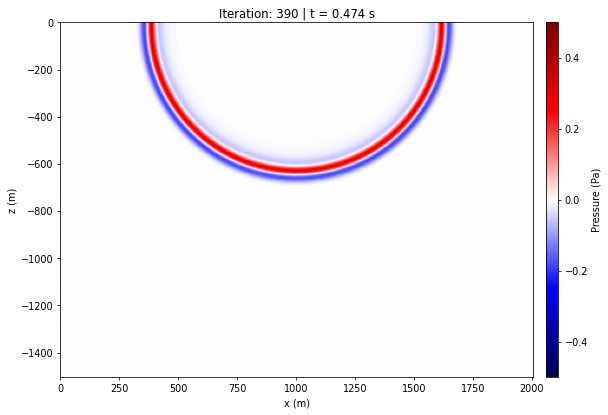

In [10]:
sim.snapshot(390, embed=True, cutoff=0.5)

In [11]:
model2 = add_layer(model, z=500, velocity=2000, density=1500)

In [12]:
sim2 = Acoustic(model=model2, verbose=True)

In [13]:
sim2.add_point_source_physical((1000,0), RickerWavelet(1,60))

In [14]:
sim2.run(700)

Output()

In [15]:
sim2.animate_physical(every=10, embed=True, dpi=50, cutoff=0.5)

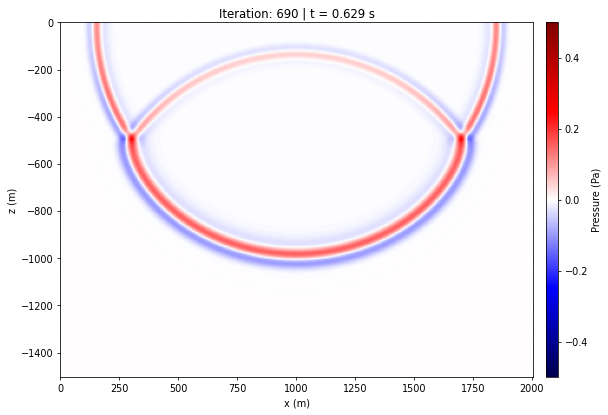

In [16]:
sim2.snapshot(690, embed=True, cutoff=0.5)

In [17]:
layers = [
    {"z":500,"velocity":2000, "density":1500},
    {"z":1000,"velocity":2500,"density":2000}
]


In [18]:
model3 = add_layers(model,layers)

In [19]:
sim3 = Acoustic(model3,verbose=True)

In [20]:
sim3.add_point_source_physical((1000,0),RickerWavelet(1,60))

In [21]:
sim3.run(1400)

Output()

In [22]:
sim3.animate_physical(every=10, embed=True, dpi=50, cutoff=0.5)

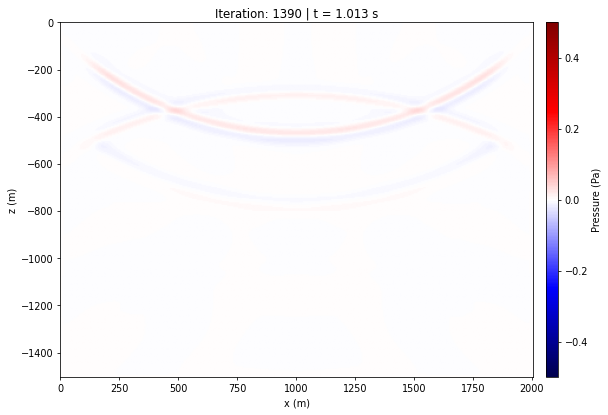

In [23]:
sim3.snapshot(1390, embed=True, cutoff=0.5)